<a href="https://colab.research.google.com/github/fasih779/deep-learning/blob/master/functional%20Api.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from keras.preprocessing import image

In [2]:
# ------------------------------
# 1️⃣ Install Kaggle and set token
# ------------------------------
!pip install kaggle --quiet

import os
import json

# Set your Kaggle API token here
KAGGLE_USERNAME = "Fasih Malhi"  # Replace with your username
KAGGLE_KEY = "KGAT_2d2bd05f78ed75132defa1da67aa15f5"  # Your token

# Create kaggle.json file
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
os.chmod("/root/.kaggle/kaggle.json", 0o600)

# ------------------------------
# 2️⃣ Download UTKFace dataset
# ------------------------------
!kaggle datasets download -d jangedoo/utkface-new --force

# Unzip dataset
!unzip -q utkface-new.zip -d utkface_dataset


Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
 87% 288M/331M [00:00<00:00, 834MB/s] 
100% 331M/331M [00:00<00:00, 794MB/s]


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [4]:
import tensorflow.keras as keras
import os
import shutil

image_size = (256, 256)
batch_size = 32

original_dataset_dir = "/content/utkface_dataset/UTKFace"
base_dir = "/content/utkface_gender_dataset" # New directory for restructured data

# Create new directories for male and female
male_dir = os.path.join(base_dir, '0_male')
female_dir = os.path.join(base_dir, '1_female')

os.makedirs(male_dir, exist_ok=True)
os.makedirs(female_dir, exist_ok=True)

# Function to parse gender from filename
def get_gender_code(filename):
    # Filename format: [age]_[gender]_[race]_[date].jpg.chip.jpg
    # Gender is the second element (index 1), 0 for male, 1 for female
    parts = filename.split('_')
    if len(parts) > 1:
        return int(parts[1])
    return -1 # Indicate error or unknown

# Move images to respective gender directories
print(f"Restructuring dataset from {original_dataset_dir} to {base_dir}...")
processed_count = 0
for img_name in os.listdir(original_dataset_dir):
    # Only process image files, ignoring other potential files or directories
    if img_name.endswith(('.jpg', '.chip.jpg', '.png', '.jpeg', '.bmp', '.gif')):
        gender_code = get_gender_code(img_name)
        if gender_code == 0: # Male
            shutil.move(os.path.join(original_dataset_dir, img_name), os.path.join(male_dir, img_name))
            processed_count += 1
        elif gender_code == 1: # Female
            shutil.move(os.path.join(original_dataset_dir, img_name), os.path.join(female_dir, img_name))
            processed_count += 1
print(f"Finished restructuring. Moved {processed_count} images.")


Restructuring dataset from /content/utkface_dataset/UTKFace to /content/utkface_gender_dataset...
Finished restructuring. Moved 23708 images.


In [5]:
!ls -R /content/utkface_dataset

Streaming output truncated to the last 5000 lines.
 52_0_3_20170113184200775.jpg.chip.jpg
 52_0_3_20170113190623929.jpg.chip.jpg
 52_0_3_20170117190840617.jpg.chip.jpg
 52_0_3_20170119160357804.jpg.chip.jpg
 52_0_3_20170119181010188.jpg.chip.jpg
 52_0_3_20170119200211340.jpg.chip.jpg
 52_0_3_20170119200241996.jpg.chip.jpg
 52_0_3_20170119200259595.jpg.chip.jpg
 52_0_3_20170119200407188.jpg.chip.jpg
 52_0_3_20170119204331863.jpg.chip.jpg
 52_0_3_20170119204337838.jpg.chip.jpg
 52_0_3_20170119205638160.jpg.chip.jpg
 52_0_3_20170119205639336.jpg.chip.jpg
 52_0_3_20170119205641007.jpg.chip.jpg
 52_0_3_20170119205647136.jpg.chip.jpg
 52_0_3_20170119205650336.jpg.chip.jpg
 52_0_3_20170119205700727.jpg.chip.jpg
 52_0_3_20170119205708991.jpg.chip.jpg
 52_0_3_20170119205712208.jpg.chip.jpg
 52_0_3_20170119205713544.jpg.chip.jpg
 52_0_3_20170119205715174.jpg.chip.jpg
 52_0_3_20170119205716424.jpg.chip.jpg
 52_0_3_20170119205717649.jpg.chip.jpg
 52_0_3_20170119205733615.jpg.chip.jpg
 52_0_3_20170

In [6]:

# Now create datasets from the restructured directory
train_ds = keras.utils.image_dataset_from_directory(
    base_dir,
    labels="inferred",
    label_mode="binary",
    batch_size=batch_size,
    image_size=image_size,
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset="training"
)

val_ds = keras.utils.image_dataset_from_directory(
    base_dir,

    label_mode="binary",

    batch_size=batch_size,
    image_size=image_size,
    shuffle=True,
    seed=42,
    validation_split=0.2,
    subset="validation"
)

Found 23708 files belonging to 2 classes.
Using 18967 files for training.
Found 23708 files belonging to 2 classes.
Using 4741 files for validation.


In [20]:
import tensorflow as tf

In [31]:
import tensorflow as tf
import os
import pathlib

def extract_labels(file_path):
    # Filename format: [age]_[gender]_[race]_[date].jpg.chip.jpg
    file_name = tf.strings.split(file_path, os.path.sep)[-1]
    parts = tf.strings.split(file_name, '_')
    age = tf.strings.to_number(parts[0], out_type=tf.float32)
    gender = tf.strings.to_number(parts[1], out_type=tf.float32)
    return gender, age

def process_path(file_path):
    label_gender, label_age = extract_labels(file_path)
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [256, 256])
    img = img / 255.0
    # Keys must match the 'name' attribute in the output layers
    return img, {'gender': label_gender, 'age': label_age}

data_dir = pathlib.Path(base_dir)
list_ds = tf.data.Dataset.list_files(str(data_dir/'*/*'), shuffle=True)

val_size = int(23708 * 0.2)
train_ds = list_ds.skip(val_size)
val_ds = list_ds.take(val_size)

train_ds = train_ds.map(process_path).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(process_path).batch(32).prefetch(tf.data.AUTOTUNE)

In [8]:
from keras.layers import *
from keras import models

In [28]:
input_layer=Input(shape=(256,256,3))

In [23]:
X=Conv2D(32,(3,3),activation='relu')(input_layer)
y=MaxPooling2D((2,2))(X)
z=Conv2D(64,(3,3),activation='relu')(y)
a=MaxPooling2D((2,2))(z)
b=Conv2D(128,(3,3),activation='relu')(a)
c=MaxPooling2D((2,2))(b)
d=Flatten()(c)
e=Dense(128,activation='relu')(d)
f=Dense(64,activation='sigmoid')(e)

# Adding explicit names to match the dataset keys
output_layer1=Dense(1,activation='sigmoid',name='gender')(f)
output_layer2=Dense(1,activation='linear',name='age')(f)

In [24]:
model=models.Model(inputs=input_layer,outputs=[output_layer1,output_layer2])

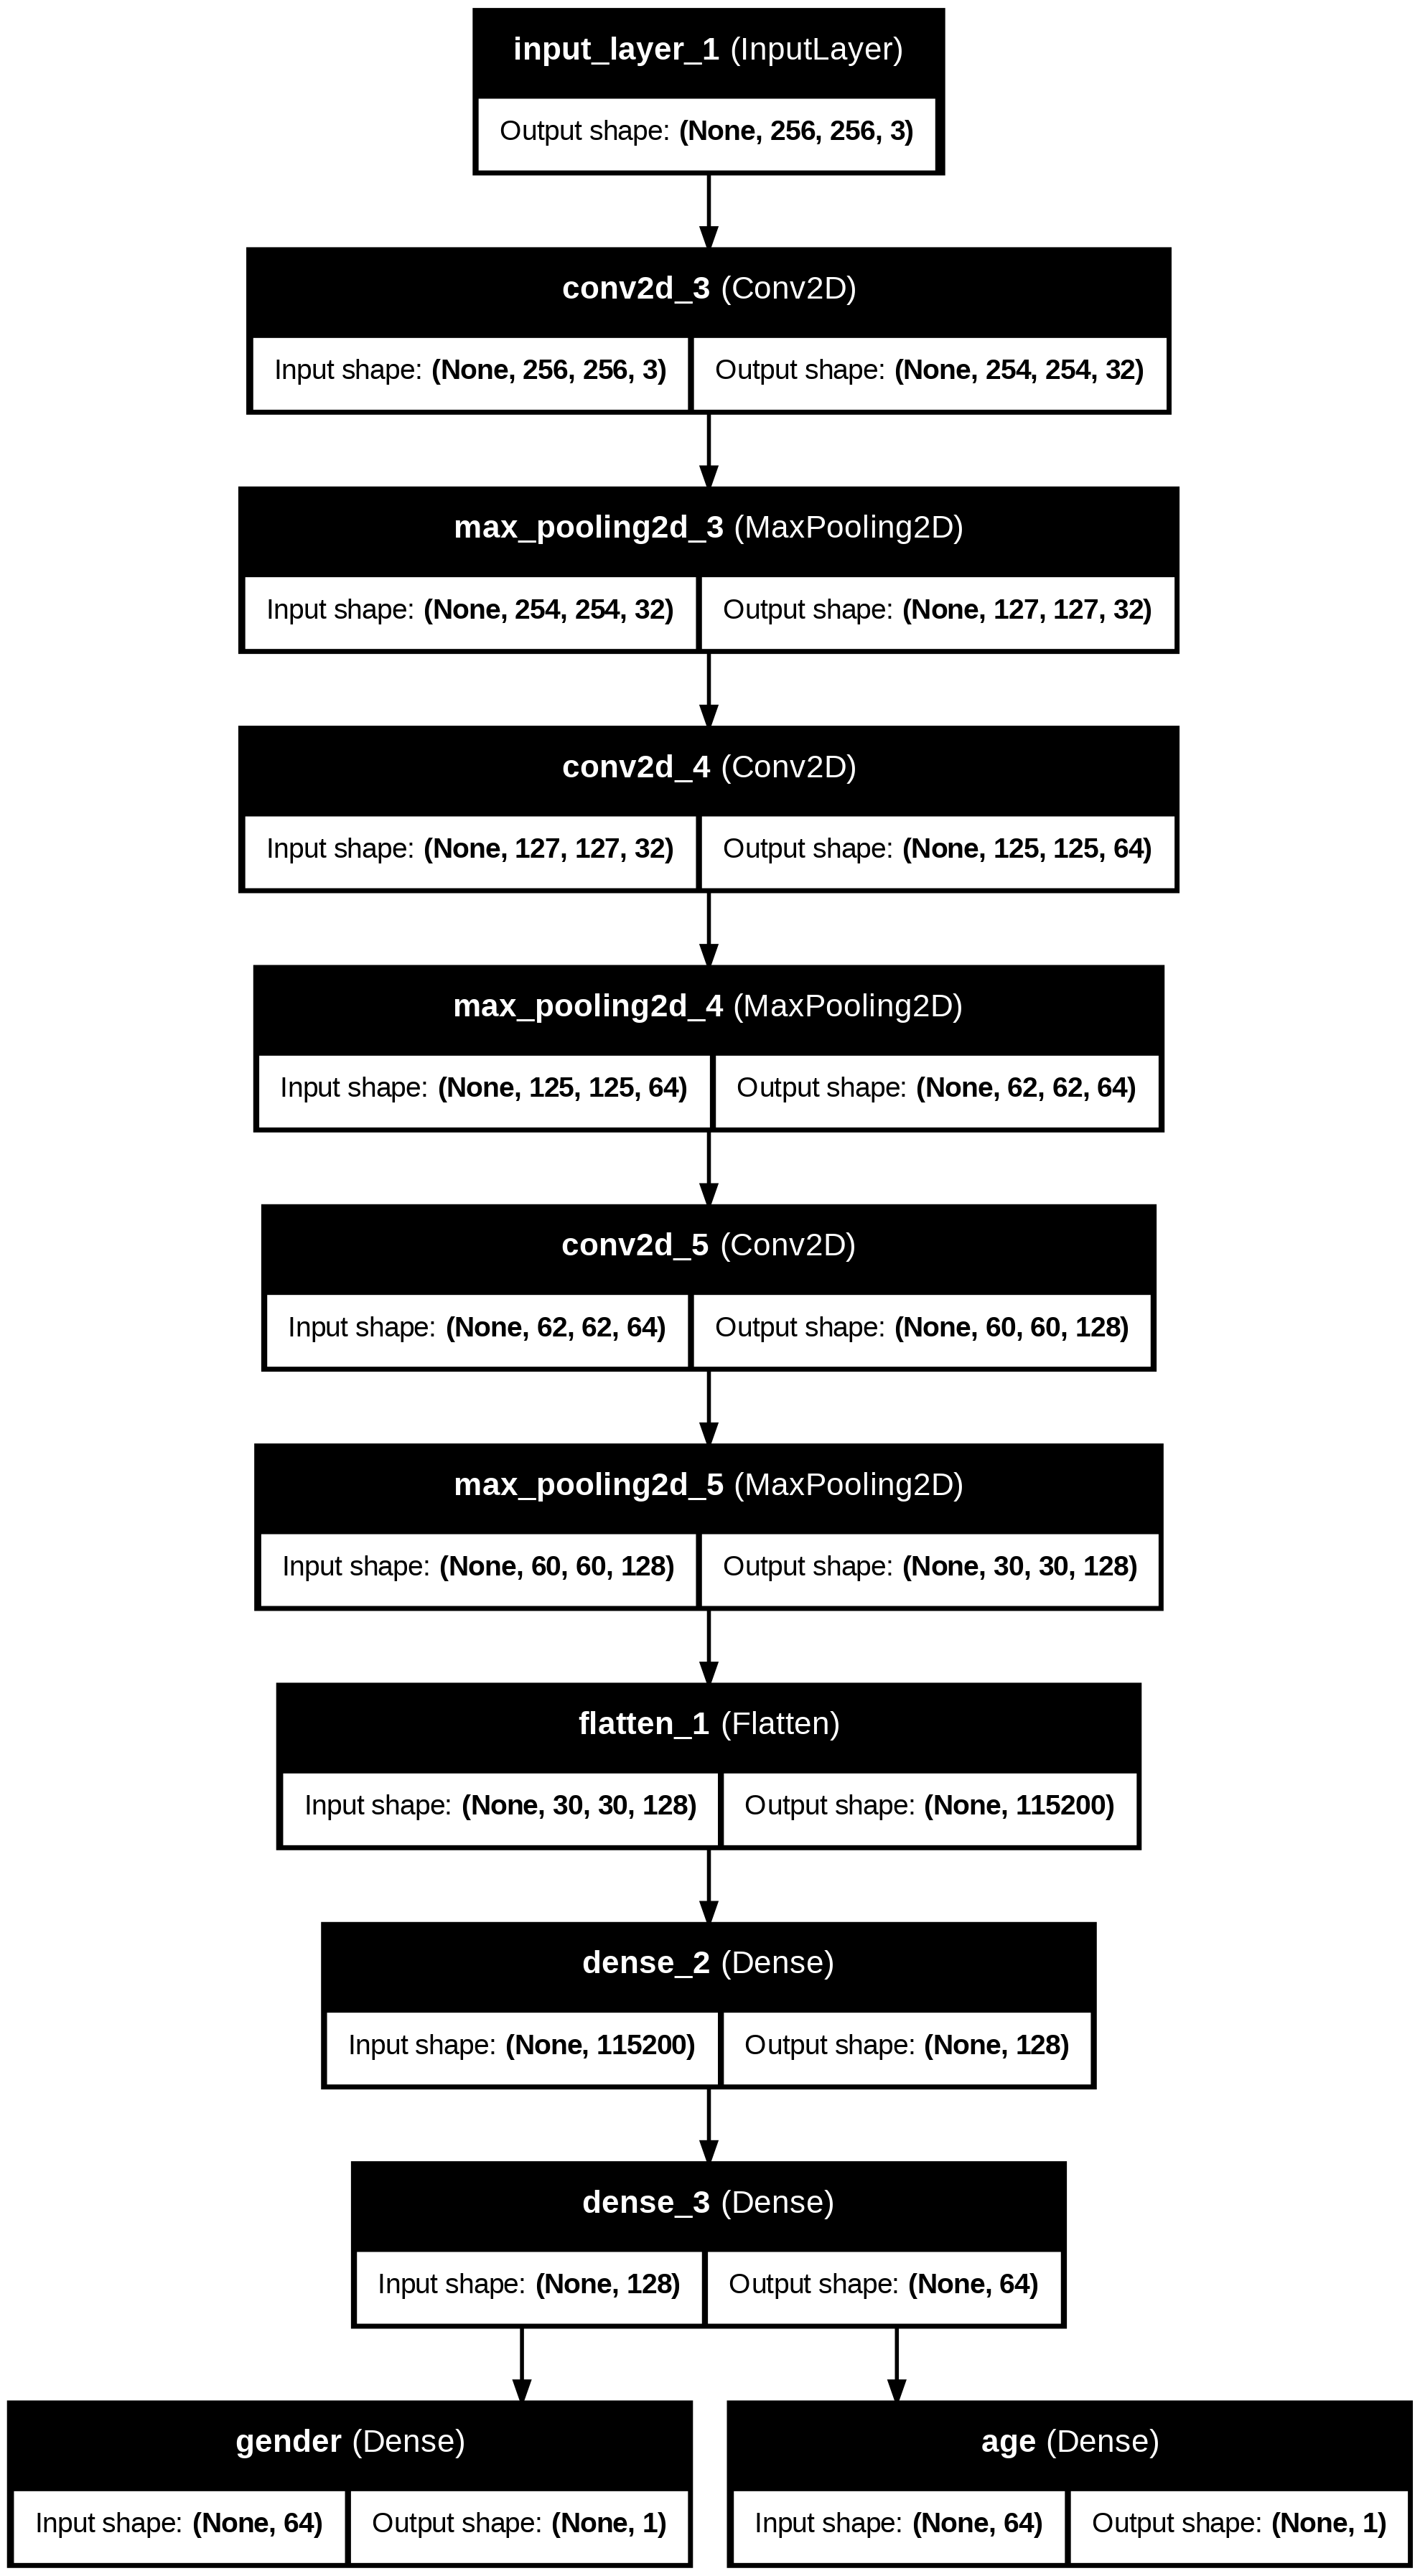

In [25]:
from keras.utils import plot_model
from tensorflow.keras.utils import plot_model

# 'model' is your Functional API model
plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)


In [32]:
model.compile(
    optimizer='adam',
    loss={'gender': 'binary_crossentropy', 'age': 'mse'},
    metrics={'gender': 'accuracy', 'age': 'mae'}
)

In [33]:
model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 68s 92ms/step - age_loss: 961.4318 - age_mae: 25.1935 - gender_accuracy: 0.5141 - gender_loss: 0.6952 - loss: 962.1263 - val_age_loss: 525.3354 - val_age_mae: 17.0650 - val_gender_accuracy: 0.5144 - val_gender_loss: 0.6927 - val_loss: 525.7684
Epoch 2/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 48s 80ms/step - age_loss: 466.0355 - age_mae: 15.8073 - gender_accuracy: 0.5219 - gender_loss: 0.6925 - loss: 466.7284 - val_age_loss: 410.9615 - val_age_mae: 15.0600 - val_gender_accuracy: 0.5098 - val_gender_loss: 0.6936 - val_loss: 410.3689
Epoch 3/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 47s 80ms/step - age_loss: 398.5480 - age_mae: 15.0501 - gender_accuracy: 0.5127 - gender_loss: 0.6936 - loss: 399.2417 - val_age_loss: 413.0448 - val_age_mae: 15.6157 - val_gender_accuracy: 0.5178 - val_gender_loss: 0.6924 - val_loss: 411.5538
Epoch 4/10
593/593 ━━━━━━━━━━━━━━━━━━━━ 87s 89ms/step - age_loss: 389.6334 - age_mae: 15.1232 - gender_accuracy: 0.5267 - gender_loss: 0.6924 - loss